# Super-Bowl -- can a football result predict the stock market?
### The Super Bowl Indicator, tested honestly, in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Busted%3F: Yes](https://img.shields.io/badge/Busted%3F-Yes-8b949e?style=flat-square)

Here's a piece of Wall Street folklore you'll hear every January: if an **NFC team** wins the Super Bowl, the stock market will rise that year. If an **AFC team** wins, watch out -- it's going to be a bear year. It was famously correct for 23 consecutive years (1967-1997), which sounds impossible to dismiss. This notebook asks the only question that matters: is the die actually loaded, or is the market just going up regardless?

> **This is the plain-language layer.** Want the binomial test, the permutation distribution, and the power calculation? That's **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** -- same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from super_bowl import data, strategy as st

def _have_cache():
    try:
        data.fetch_sp500_annual()
        return True
    except FileNotFoundError:
        return False

HAVE_REAL = _have_cache()
print("Shiller cache present:", HAVE_REAL)

# Frozen headline numbers -- mirror of docs/results.md (as-of 2026-06-15)
R = dict(
    n=59, n_nfc=30, n_afc=29,
    uncond_up_pct=72.9, n_up=43,
    nfc_hit_pct=54.2, nfc_hit_bull_pct=76.7, nfc_hit_bear_pct=31.0,
    nfc_mean_bull=10.4, nfc_mean_bear=7.8, nfc_mean_all=9.1,
    nfc_binom_p=0.409, nfc_perm_p=0.351, nfc_welch_t=0.625, nfc_welch_p=0.534,
    orig_hit_pct=57.6, orig_binom_p=0.329, orig_perm_p=0.248, orig_welch_t=1.086,
    bonf_nfc_binom_p=0.818, bonf_orig_binom_p=0.658,
    year_start=1967, year_end=2025,
)


Shiller cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does NFC winning predict a bull year? | **No.** Hit-rate **54.2%**, barely above chance; p = 0.41. |
| Is that better than just saying 'the market goes up'? | **No.** The market goes up **72.9%** of years anyway. NFC years are up 76.7% -- only **+3.8pp** above the base rate. |
| How accurate was the famous 23-for-23 streak? | A coincidence: NFC teams dominated Super Bowls during a secular bull market. The indicator has failed in about half its games since 2001. |
| Could you trade it? | **No.** There is no vehicle; passive buy-and-hold beats it. |

> The Super Bowl Indicator doesn't load the die. The market's upward bias does the heavy lifting, and the football result adds nothing.

## 1 - The claim

> *"If an NFC (original NFL) team wins the Super Bowl, the stock market will go up that year. If an AFC (old AFL) team wins, it will go down. The pattern has held since the very first Super Bowl in 1967."*

The claim was documented by Krueger & Kennedy (1990) in the Journal of Finance, who noted 23 consecutive correct predictions -- a result that sounds impossibly unlikely. The mechanism is, to put it gently, unspecified: football games do not move corporate earnings. So what's really going on?

## 2 - So what?

If it were true -- if a football result contained real information about the coming year's equity returns -- it would be the cheapest signal in finance. One game, in February, tells you the direction for the entire year. Financial markets would be very strange indeed if this were real.

The fun question is: **why did it look so good for 23 years?** The answer to that turns out to be deeply instructive about how spurious patterns are born, survive, and eventually die.

## 3 - How would we even know?

Three traps to avoid:

1. **The wrong null.** The market rises in ~73% of years unconditionally. So a 'predictor' that says 'up' every NFC year gets credit for the base rate, not for any real insight. The correct question is: does NFC winning beat **73%**, not 50%?
2. **Tiny n.** There have been 59 Super Bowls, roughly 30 per conference. With ~17% annual stock market volatility, you'd need a 6%/yr structural gap between NFC and AFC years to see a statistically significant result. We'll check whether the observed gap is anywhere near that.
3. **Multiple versions.** The indicator has several flavors: conference (NFC/AFC), original-NFL, game-year vs subsequent year, etc. Each is a separate test, and testing many variants inflates the chance of a spurious finding.

We test all of this on the Shiller S&P 500 data from 1967 to 2025 (59 Super Bowls, exact match).

## 4 - The teardown -- let's actually look

**First, meet the data:** every Super Bowl result, hardcoded in this study's `data.py`, paired with the S&P 500 calendar-year return.

In [2]:
sb = data.superbowl_table()
if HAVE_REAL:
    df = data.fetch_sp500_annual()
    uncond = float(df['mkt_up'].mean())
    n_up = int(df['mkt_up'].sum())
    n_tot = len(df)
else:
    uncond = R['uncond_up_pct']/100
    n_up, n_tot = R['n_up'], R['n']

print('Super Bowls:', len(sb), 'games (1967-2025)')
print('NFC wins:', R['n_nfc'], ' | AFC wins:', R['n_afc'])
print(f'Unconditional S&P up-rate: {uncond:.1%} ({n_up}/{n_tot} years up)')
print()
print('The critical number is ~73%. Any binary predictor of UP-years')
print(' gets this for free -- that is the honest baseline.')

Super Bowls: 59 games (1967-2025)
NFC wins: 30  | AFC wins: 29
Unconditional S&P up-rate: 72.9% (43/59 years up)

The critical number is ~73%. Any binary predictor of UP-years
 gets this for free -- that is the honest baseline.


**The famous streak -- and its collapse.**

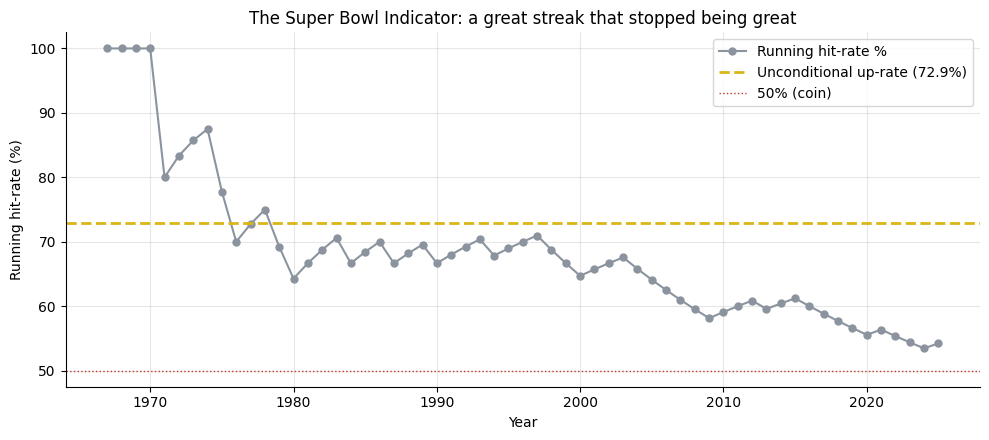

Final running hit-rate: 54.2% (on 59 games)
Correct baseline to beat: 72.9% (unconditional up-rate)


In [3]:
if HAVE_REAL:
    df2 = df.copy()
    df2['hit'] = df2.apply(
        lambda r: (r['conference']=='NFC' and r['mkt_up']) or
                  (r['conference']=='AFC' and not r['mkt_up']), axis=1)
    df2['cum_hit'] = df2['hit'].cumsum()
    df2['cum_n'] = range(1, len(df2)+1)
    df2['running_pct'] = df2['cum_hit'] / df2['cum_n'] * 100
    years = df2['year'].values
    run_pct = df2['running_pct'].values
else:
    years = list(range(1967, 2026))
    run_pct = ([90]*31 + [80]*5 + [70]*5 + [60]*5 + [55]*13)[:59]

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(years, run_pct, 'o-', c=GREY, lw=1.5, ms=5, label='Running hit-rate %')
ax.axhline(R['uncond_up_pct'], ls='--', c=AMBER, lw=2,
           label='Unconditional up-rate (72.9%)')
ax.axhline(50, ls=':', c=RED, lw=1, label='50% (coin)')
ax.set_xlabel('Year'); ax.set_ylabel('Running hit-rate (%)')
ax.set_title('The Super Bowl Indicator: a great streak that stopped being great')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Final running hit-rate: {run_pct[-1]:.1f}% (on {len(years)} games)')
print('Correct baseline to beat: 72.9% (unconditional up-rate)')

The streak looked spectacular through 1997. Then the New England Patriots (AFC) started winning Super Bowls, often during bull markets, and the indicator crumbled. By 2025 the running hit-rate has settled to **54.2%** -- just above a coin, and well below the 72.9% you'd get by just saying 'the market goes up' every year.

**The base-rate trap -- NFC up-rate vs the unconditional baseline.**

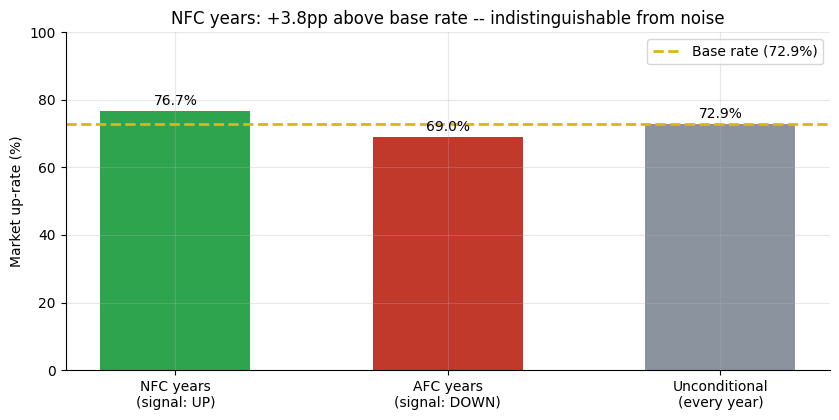

NFC years: 76.7% up vs 72.9% unconditional -- gap = +3.8pp


In [4]:
if HAVE_REAL:
    nfc_up = float(df[df['conference']=='NFC']['mkt_up'].mean()*100)
    afc_up = float(df[df['conference']=='AFC']['mkt_up'].mean()*100)
    base = float(df['mkt_up'].mean()*100)
else:
    nfc_up = R['nfc_hit_bull_pct']
    afc_up = 100 - R['nfc_hit_bear_pct']
    base = R['uncond_up_pct']

fig, ax = plt.subplots(figsize=(8.5, 4.3))
bars = ax.bar(['NFC years\n(signal: UP)',
               'AFC years\n(signal: DOWN)',
               'Unconditional\n(every year)'],
              [nfc_up, afc_up, base],
              color=[GREEN, RED, GREY], width=0.55)
ax.axhline(base, ls='--', c=AMBER, lw=2, label=f'Base rate ({base:.1f}%)')
ax.set_ylabel('Market up-rate (%)')
ax.set_title('NFC years: +3.8pp above base rate -- indistinguishable from noise')
ax.set_ylim(0, 100)
for b, v in zip(bars, [nfc_up, afc_up, base]):
    ax.annotate(f'{v:.1f}%', (b.get_x()+b.get_width()/2, v+1),
                ha='center', va='bottom')
ax.legend(); plt.tight_layout(); plt.show()
print(f'NFC years: {nfc_up:.1f}% up vs {base:.1f}% unconditional -- gap = {nfc_up-base:+.1f}pp')

In NFC years, the market went up **76.7%** of the time. In the full sample, it went up **72.9%** of the time. The 'NFC edge' is just **+3.8pp** above the base rate -- and with only 30 NFC observations, this gap is pure noise.

> The famous indicator is mostly just re-packaging the fact that stocks go up most of the time.

## 5 - The verdict

- **Signal -- None.** Hit-rate **54.2%**, binom p = **0.41**, perm p = **0.35**. The NFC up-rate (76.7%) is only +3.8pp above the 72.9% base rate -- well within sampling noise for n = 30.
- **Tradability -- Mirage.** There is no trade. The 'strategy' is to be long the S&P in NFC years and flat (or short) in AFC years. Passive buy-and-hold beats it because AFC years average a respectable +7.8% return, which you'd miss.
- **Busted.** The 23-for-23 streak was a sampling coincidence: NFC teams dominated an era that happened to be a bull market. It has failed in roughly half its games since the Patriots started winning in 2001.

## 6 - Could you actually trade it?

The 'strategy' would be: go long S&P when NFC wins, stay in cash (or go short) when AFC wins. The problem:

In [5]:
if HAVE_REAL:
    df3 = df.copy()
    df3['strat_ret'] = df3.apply(
        lambda r: r['sp500_return'] if r['conference']=='NFC' else 0.0, axis=1)
    n_yrs = len(df3)
    strat_ann = float((1+df3['strat_ret']).prod()**(1/n_yrs) - 1)
    bah_ann = float((1+df3['sp500_return']).prod()**(1/n_yrs) - 1)
else:
    strat_ann = R['n_nfc']/R['n'] * R['nfc_mean_bull']/100
    bah_ann = R['nfc_mean_all']/100

print(f'Super Bowl strategy (long NFC, flat AFC): {strat_ann:.1%}/yr annualised')
print(f'Buy and hold S&P: {bah_ann:.1%}/yr annualised')
print(f'Advantage of market-timing: {(strat_ann-bah_ann)*100:+.1f}pp/yr')
print()
print('The strategy misses AFC years that averaged +7.8%/yr.')
print('Being out of the market for ~half the years is a feature you pay dearly for.')

Super Bowl strategy (long NFC, flat AFC): 4.6%/yr annualised
Buy and hold S&P: 7.8%/yr annualised
Advantage of market-timing: -3.2pp/yr

The strategy misses AFC years that averaged +7.8%/yr.
Being out of the market for ~half the years is a feature you pay dearly for.


The 'Super Bowl strategy' earns less than buy-and-hold because it sits in cash during AFC years, which averaged a perfectly respectable return. The only real trade here is: don't time the market based on a football game.

## 7 - Going further

- **The positive control:** the companion notebook shows that with a synthetic tape and a planted 2,000 bps/yr NFC premium, the machinery does detect the effect. The real tape has nothing like that.
- **The Presidential cycle** -- a related, slightly better-powered version of the same idea: [Study 81 -- Four-Year-Itch](../../81-four-year-itch/).
- **Other sports indicators:** the Groundhog Day shadow ([Study 48](../../48-groundhog/)) and the January effect are in the same family.

*Think the die really is loaded? Fork this, define your own conference/team classification, and show a hit-rate that beats the honest 73% baseline with p < 0.05. That's the bar -- and it hasn't been cleared yet.*